In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib seaborn

import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': True,
})
PALETTE = sns.color_palette('tab20', 20)

print('torch  :', torch.__version__)
print('cuda   :', torch.cuda.is_available())
print('numpy  :', np.__version__)

torch  : 2.10.0+cu128
cuda   : True
numpy  : 2.0.2


In [ ]:

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RU_DIR     = Path('/content/drive/MyDrive/medical_protocols/gold_standard_md')
OUTPUT_DIR = Path('/content/drive/MyDrive/medical_protocols/ru_embeddings')
PLOT_DIR   = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

MIN_CHARS   = 200    # must match EN pipeline
N_CLUSTERS  = 12     # primary k for KMeans
K_RANGE     = range(4, 21)   # range for optimal-k search
BATCH_SIZE  = 32
MODEL_NAME  = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
TSNE_PERP   = 40     # t-SNE perplexity (tune if n_sections changes)

print(f'RU_DIR    : {RU_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')
print(f'PLOT_DIR  : {PLOT_DIR}')
print(f'MIN_CHARS : {MIN_CHARS}  ← must equal EN pipeline')
print(f'N_CLUSTERS: {N_CLUSTERS}')
print(f'K_RANGE   : {list(K_RANGE)}')

RU_DIR    : /content/drive/MyDrive/medical_protocols/gold_standard_md
OUTPUT_DIR: /content/drive/MyDrive/medical_protocols/ru_embeddings
PLOT_DIR  : /content/drive/MyDrive/medical_protocols/ru_embeddings/plots
MIN_CHARS : 200  ← must equal EN pipeline
N_CLUSTERS: 12
K_RANGE   : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2", device=device)
print(f"Model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded on cuda


In [ ]:
def split_markdown_sections(md_text: str, min_chars: int = 200):
    """
    Split a Markdown document by ## headers.

    Returns a list of (title: str, body: str) tuples where
    len(body) >= min_chars. Sections without a header are labelled
    'NO_HEADER' and retained if long enough.

    Parameters
    ----------
    md_text   : raw markdown string
    min_chars : minimum body character count to retain a section
    """
    md_text = md_text.replace('\r\n', '\n').strip()
    parts   = re.split(r'(?=^##\s+)', md_text, flags=re.M)
    out     = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        lines = part.splitlines()
        if lines and lines[0].startswith('##'):
            title = lines[0].lstrip('#').strip()
            body  = '\n'.join(lines[1:]).strip()
        else:
            title = 'NO_HEADER'
            body  = part
        if len(body) >= min_chars:
            out.append((title, body))
    return out


ru_files = sorted(RU_DIR.glob('*.md'))
print(f'RU protocol files found: {len(ru_files)}')

section_counts = []
for fp in ru_files:
    txt = fp.read_text(encoding='utf-8', errors='ignore')
    n   = len(split_markdown_sections(txt, min_chars=MIN_CHARS))
    section_counts.append({'file': fp.name, 'n_sections': n})

df_counts = pd.DataFrame(section_counts)
print(f'\nSection count stats (min_chars={MIN_CHARS}):')
print(df_counts['n_sections'].describe().round(1).to_string())
print(f'\nTotal sections: {df_counts["n_sections"].sum()}')


RU protocol files found: 84

Section count stats (min_chars=200):
count     84.0
mean      29.6
std       26.6
min        2.0
25%       16.8
50%       22.0
75%       33.2
max      167.0

Total sections: 2490


In [ ]:
all_vecs = []
all_rows = []

for fp in tqdm(ru_files, desc='Embedding RU sections'):
    pt_path   = OUTPUT_DIR / f'ru_sections_{fp.stem}.pt'
    meta_path = OUTPUT_DIR / f'ru_sections_{fp.stem}.json'

    text     = fp.read_text(encoding='utf-8', errors='ignore')
    sections = split_markdown_sections(text, min_chars=MIN_CHARS)
    if not sections:
        continue

    titles = [t for t, _ in sections]
    bodies = [b for _, b in sections]

    if pt_path.exists() and meta_path.exists():
        embs_cpu = torch.load(pt_path, map_location='cpu')
    else:
        embs     = model.encode(bodies, convert_to_tensor=True,
                                batch_size=BATCH_SIZE, show_progress_bar=False)
        embs_cpu = embs.detach().cpu()
        torch.save(embs_cpu, pt_path)
        meta = {'file': fp.name, 'section_count': len(sections),
                'titles': titles, 'char_lengths': [len(b) for b in bodies]}
        meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2),
                             encoding='utf-8')

    for i, (title, body) in enumerate(sections):
        all_vecs.append(embs_cpu[i])
        all_rows.append({
            'file':          fp.name,
            'protocol':      fp.stem,
            'section_id':    i,
            'section_title': title,
            'section_chars': len(body),
            'text_preview':  body[:300],
        })

X  = torch.stack(all_vecs).numpy()   # (n_sections, emb_dim)
df = pd.DataFrame(all_rows)
print(f'Total sections  : {len(df)}')
print(f'Embedding matrix: {X.shape}')

Embedding RU sections: 100%|██████████| 84/84 [00:00<00:00, 599.58it/s]

Total sections  : 2490
Embedding matrix: (2490, 768)


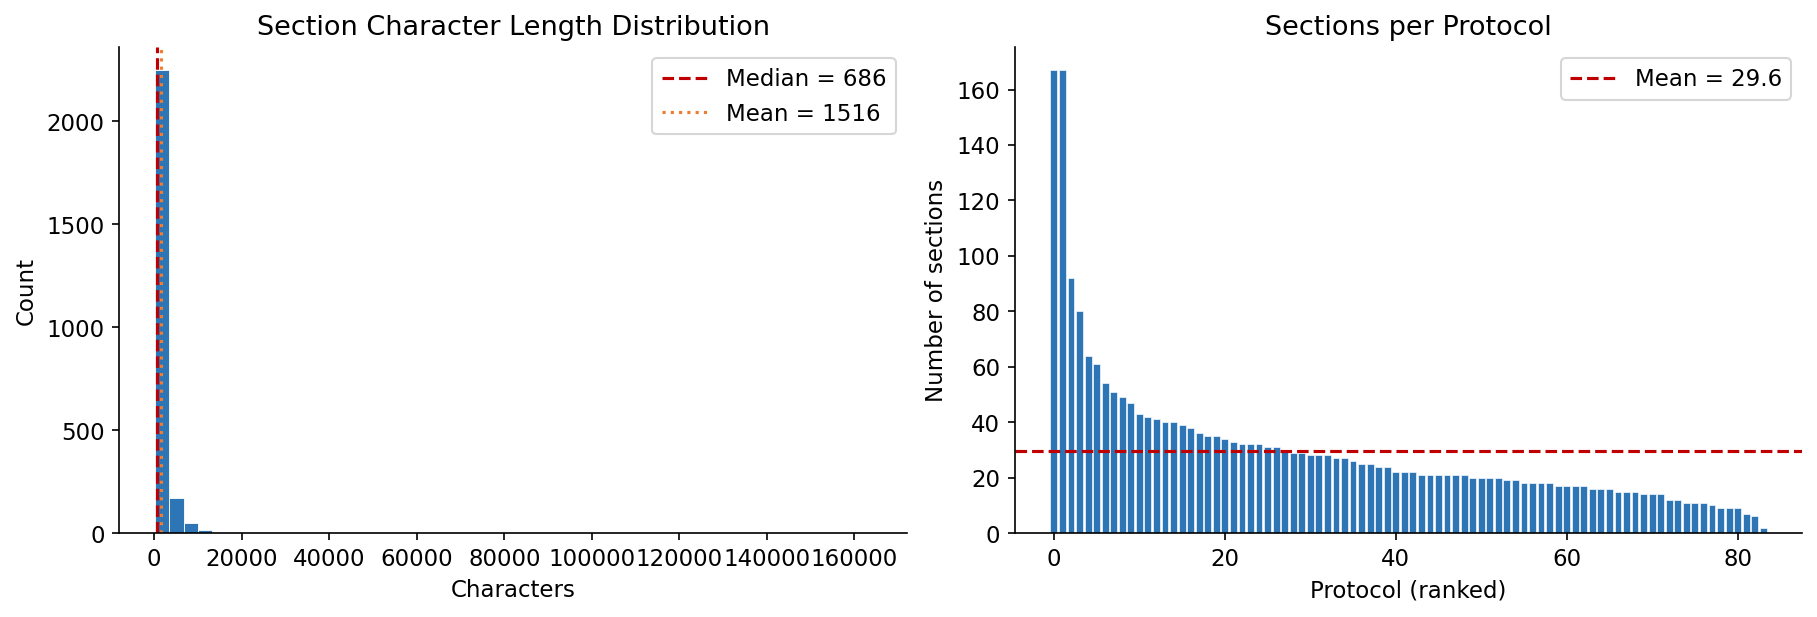


Corpus statistics:


,chars
count,2490.0
mean,1515.9
std,4094.0
min,200.0
25%,367.2
50%,685.5
75%,1539.0
max,163814.0
total_sections,2490.0
n_protocols,84.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Histogram of section character lengths ────────────────────────────────────
axes[0].hist(df['section_chars'], bins=50, color='#2E75B6', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['section_chars'].median(), color='#C00000', linewidth=1.5,
                linestyle='--', label=f'Median = {df["section_chars"].median():.0f}')
axes[0].axvline(df['section_chars'].mean(), color='#ED7D31', linewidth=1.5,
                linestyle=':', label=f'Mean = {df["section_chars"].mean():.0f}')
axes[0].set_title('Section Character Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── Sections per protocol ─────────────────────────────────────────────────────
spp = df.groupby('protocol')['section_id'].count().sort_values(ascending=False)
axes[1].bar(range(len(spp)), spp.values, color='#2E75B6', edgecolor='white', linewidth=0.3)
axes[1].axhline(spp.mean(), color='#C00000', linewidth=1.5, linestyle='--',
                label=f'Mean = {spp.mean():.1f}')
axes[1].set_title('Sections per Protocol')
axes[1].set_xlabel('Protocol (ranked)')
axes[1].set_ylabel('Number of sections')
axes[1].legend()

fig.savefig(PLOT_DIR / 'fig_section_length_distribution.png', bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
stats = df['section_chars'].describe().rename('chars').to_frame()
stats.loc['total_sections'] = len(df)
stats.loc['n_protocols']    = df['protocol'].nunique()
print('\nCorpus statistics:')
display(stats.round(1))


Sweeping k from 4 to 20...


k sweep: 100%|██████████| 17/17 [00:03<00:00,  4.48it/s]


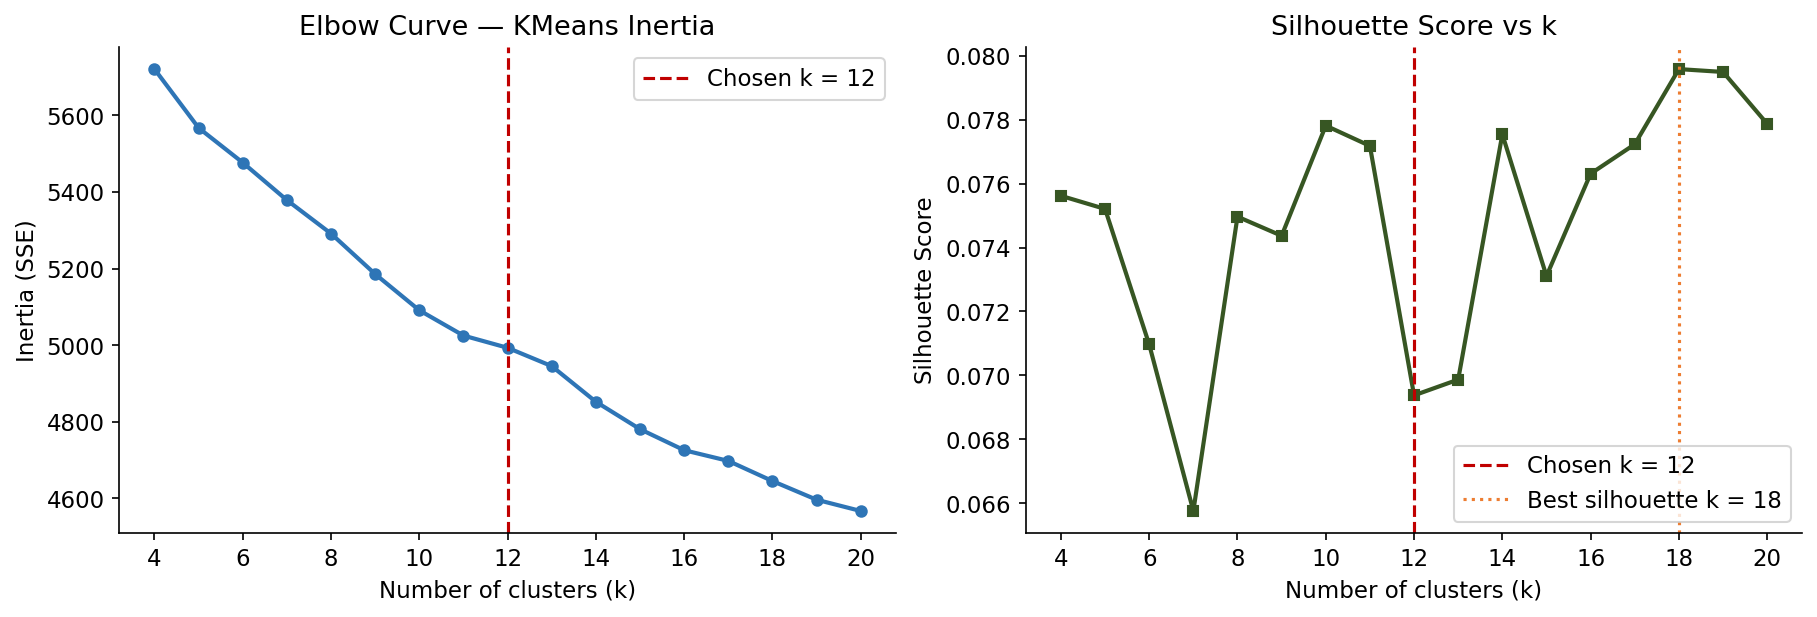


Best silhouette k = 18  (score = 0.0796)
Chosen k          = 12  (score = 0.0694)

Note: low silhouette values are expected in standardised clinical documents
where sections share overlapping terminology across protocols.


In [ ]:
inertias    = []
sil_scores  = []
k_list      = list(K_RANGE)

print(f'Sweeping k from {k_list[0]} to {k_list[-1]}...')
for k in tqdm(k_list, desc='k sweep'):
    km  = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_list, inertias, 'o-', color='#2E75B6', linewidth=2, markersize=5)
axes[0].axvline(N_CLUSTERS, color='#C00000', linewidth=1.5, linestyle='--',
                label=f'Chosen k = {N_CLUSTERS}')
axes[0].set_title('Elbow Curve — KMeans Inertia')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].legend()

axes[1].plot(k_list, sil_scores, 's-', color='#375623', linewidth=2, markersize=5)
axes[1].axvline(N_CLUSTERS, color='#C00000', linewidth=1.5, linestyle='--',
                label=f'Chosen k = {N_CLUSTERS}')
best_k = k_list[int(np.argmax(sil_scores))]
axes[1].axvline(best_k, color='#ED7D31', linewidth=1.5, linestyle=':',
                label=f'Best silhouette k = {best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

fig.savefig(PLOT_DIR / 'fig_optimal_k_sweep.png', bbox_inches='tight')
plt.show()

print(f'\nBest silhouette k = {best_k}  (score = {max(sil_scores):.4f})')
print(f'Chosen k          = {N_CLUSTERS}  (score = {sil_scores[k_list.index(N_CLUSTERS)]:.4f})')
print(f'\nNote: low silhouette values are expected in standardised clinical documents')
print(f'where sections share overlapping terminology across protocols.')

In [ ]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init='auto')
labels = kmeans.fit_predict(X)
df['cluster'] = labels

sil_global = silhouette_score(X, labels)
sil_per_sample = silhouette_samples(X, labels)
df['silhouette_sample'] = sil_per_sample

print(f'Global silhouette score (k={N_CLUSTERS}): {sil_global:.4f}')
print(f'Per-cluster silhouette summary:')
sil_by_cluster = (
    df.groupby('cluster')['silhouette_sample']
    .agg(['mean', 'median', 'std'])
    .round(4)
    .sort_values('mean', ascending=False)
)
display(sil_by_cluster)

out_csv = OUTPUT_DIR / 'ru_clusters_sections.csv'
df.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')

Global silhouette score (k=12): 0.0694
Per-cluster silhouette summary:


,mean,median,std
cluster,,,
9,0.4120,0.4365,0.1520
5,0.3353,0.3646,0.1457
0,0.1942,0.1717,0.1126
6,0.1058,0.1010,0.0480
7,0.0918,0.0815,0.0767
8,0.0593,0.0577,0.0360
2,0.0527,0.0541,0.0313
3,0.0327,0.0331,0.0456
11,0.0267,0.0201,0.0536



Saved: /content/drive/MyDrive/medical_protocols/ru_embeddings/ru_clusters_sections.csv


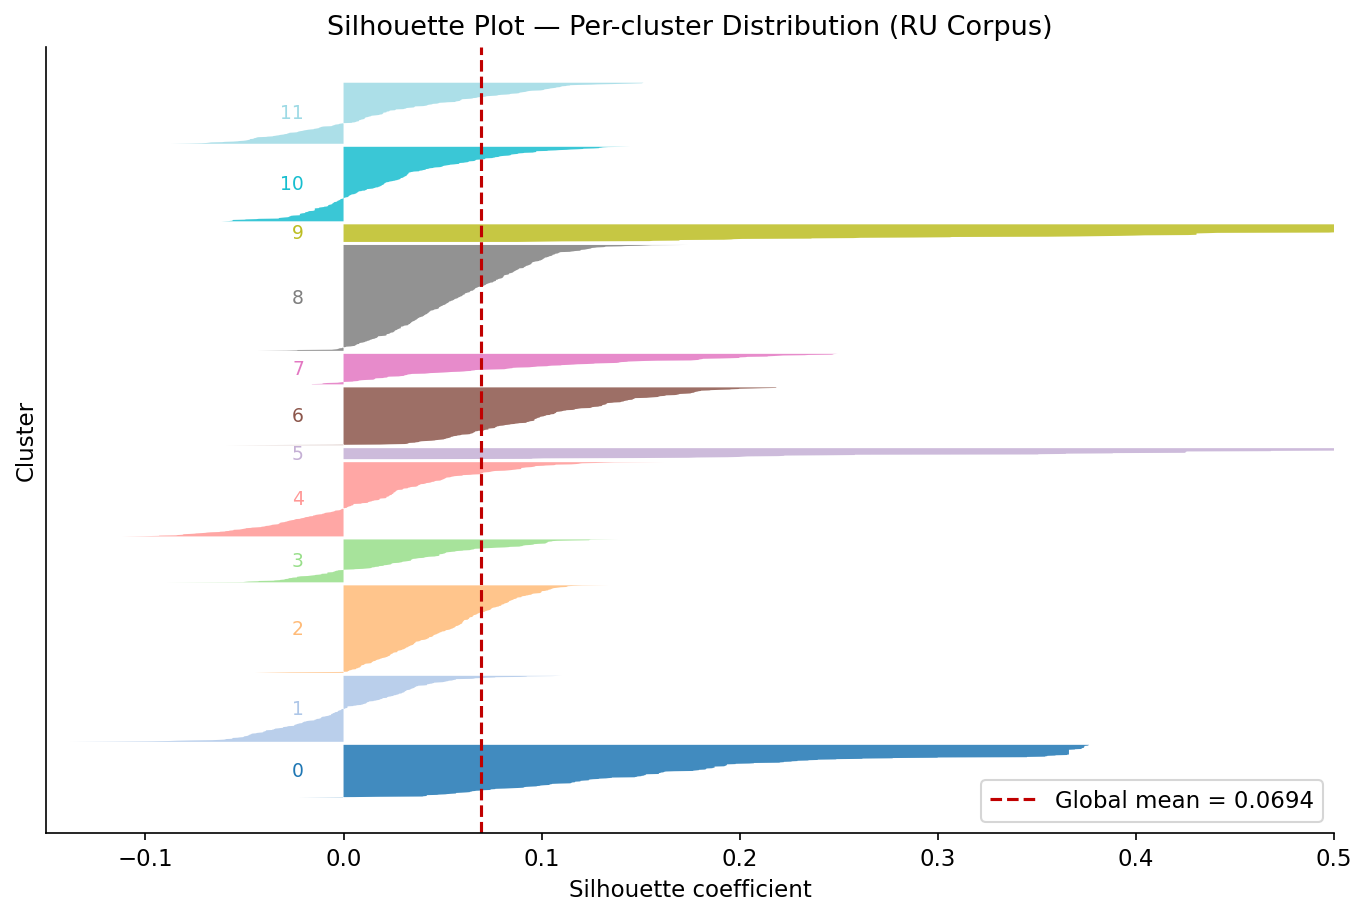

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

y_lower = 10
cluster_ids = sorted(df['cluster'].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_ids)))

for idx, c in enumerate(cluster_ids):
    sil_vals = np.sort(sil_per_sample[labels == c])
    size_c   = len(sil_vals)
    y_upper  = y_lower + size_c

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals,
                     facecolor=colors[idx], edgecolor='none', alpha=0.85)
    ax.text(-0.02, y_lower + 0.5 * size_c, str(c), va='center', ha='right',
            fontsize=9, color=colors[idx])
    y_lower = y_upper + 10

ax.axvline(sil_global, color='#C00000', linewidth=1.5, linestyle='--',
           label=f'Global mean = {sil_global:.4f}')
ax.set_title('Silhouette Plot — Per-cluster Distribution (RU Corpus)')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(loc='lower right')
ax.set_xlim(-0.15, 0.5)

fig.savefig(PLOT_DIR / 'fig_silhouette_plot.png', bbox_inches='tight')
plt.show()

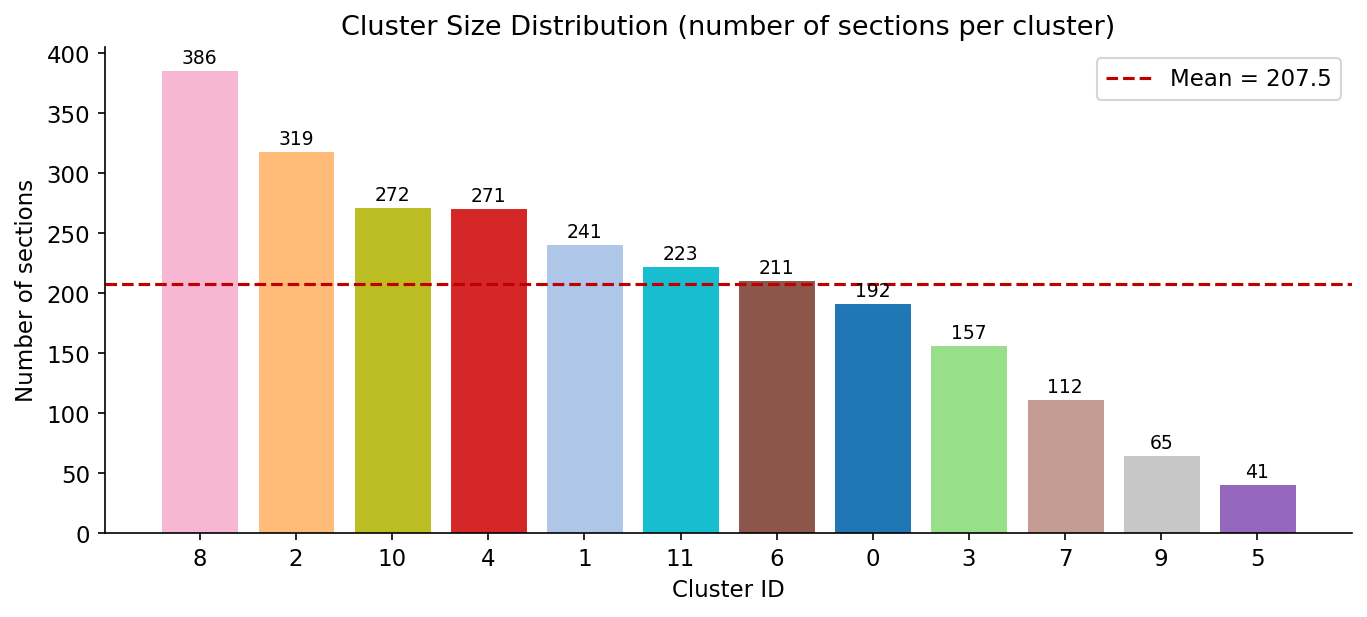

,cluster,n_sections
8,8,386
2,2,319
10,10,272
4,4,271
1,1,241
11,11,223
6,6,211
0,0,192
3,3,157
7,7,112


In [ ]:
cluster_sizes = (
    df.groupby('cluster').size()
    .reset_index(name='n_sections')
    .sort_values('n_sections', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cluster_sizes['cluster'].astype(str), cluster_sizes['n_sections'],
              color=[plt.cm.tab20(i / N_CLUSTERS) for i in cluster_sizes.index],
              edgecolor='white', linewidth=0.5)
ax.axhline(cluster_sizes['n_sections'].mean(), color='#C00000',
           linestyle='--', linewidth=1.5,
           label=f'Mean = {cluster_sizes["n_sections"].mean():.1f}')
for bar, val in zip(bars, cluster_sizes['n_sections']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_title('Cluster Size Distribution (number of sections per cluster)')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of sections')
ax.legend()

fig.savefig(PLOT_DIR / 'fig_cluster_sizes.png', bbox_inches='tight')
plt.show()
display(cluster_sizes)

In [ ]:
TOP_N = 8
title_rows = []
for c in sorted(df['cluster'].unique()):
    top = df[df['cluster'] == c]['section_title'].value_counts().head(TOP_N)
    for title, cnt in top.items():
        title_rows.append({'cluster': int(c), 'section_title': title, 'count': int(cnt)})

df_titles = pd.DataFrame(title_rows)
df_titles.to_csv(OUTPUT_DIR / 'ru_cluster_top_titles.csv', index=False)

for c in sorted(df['cluster'].unique()):
    sub = df_titles[df_titles['cluster'] == c]
    print(f'\nCluster {c:>2}  (n={len(df[df["cluster"]==c])} sections)')
    print('  ' + ', '.join(sub['section_title'].tolist()))


Cluster  0  (n=192 sections)
  1.6 Определение:, 2.2 Противопоказания к процедуре и вмешательству:, 2.3 Показания к процедуре и вмешательству:, 2.1 Цель проведения процедуры и вмешательства:, 2.1 Цель проведения процедуры и вмешательства :, 2.5 Требования к проведению процедуры и вмешательства:, 1.7 Клиническая классификация (наиболее распространенные подходы, по этиологии, стадии) ., Операции на роботизированной системе могут выполняются врачами-хирургами, имеющими:

Cluster  1  (n=241 sections)
  Жалобы:, Анамнез:, Нефрометрическая шкала R.E.N.A.L:, T - первичная опухоль, 1.7 Клиническая классификация (наиболее распространенные подходы, по этиологии, стадии) ., 1.7 Клиническая классификация (наиболее распространенные подходы, по этиологии, стадии)., ВАЖНО!, 1.3 Сокращения, используемые в протоколе:

Cluster  2  (n=319 sections)
  Физикальное обследование:, Анамнез:, 1.7 Определение:, Рекомендован пациенткам:, Инструментальные исследования:, ВАЖНО!, 1.7 Определение  :, 1.7 Определени

In [ ]:

CLUSTER_LABELS = {
    0:  'Diagnosis & Criteria',
    1:  'Pharmacotherapy',
    2:  'Surgical Procedures',
    3:  'Antenatal Monitoring',
    4:  'Risk Stratification',
    5:  'Laboratory Tests',
    6:  'Patient Management',
    7:  'Postpartum Care',
    8:  'Infection & Sepsis',
    9:  'Oncology Protocols',
    10: 'Screening & Prevention',
    11: 'Emergency Procedures',
}

df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)
print('Cluster → label mapping applied.')
display(df.groupby(['cluster', 'cluster_label']).size().reset_index(name='n_sections'))

Cluster → label mapping applied.


,cluster,cluster_label,n_sections
0,0,Diagnosis & Criteria,192
1,1,Pharmacotherapy,241
2,2,Surgical Procedures,319
3,3,Antenatal Monitoring,157
4,4,Risk Stratification,271
5,5,Laboratory Tests,41
6,6,Patient Management,211
7,7,Postpartum Care,112
8,8,Infection & Sepsis,386
9,9,Oncology Protocols,65


In [ ]:
print(f'Running t-SNE (perplexity={TSNE_PERP})... may take 2-3 min')
tsne = TSNE(n_components=2, perplexity=TSNE_PERP, random_state=SEED,
            n_iter=1000, metric='cosine', init='pca')
X_2d = tsne.fit_transform(X)
df['tsne_x'] = X_2d[:, 0]
df['tsne_y'] = X_2d[:, 1]
np.save(OUTPUT_DIR / 'tsne_coords.npy', X_2d)
print('t-SNE done.')

Running t-SNE (perplexity=40)... may take 2-3 min
t-SNE done.


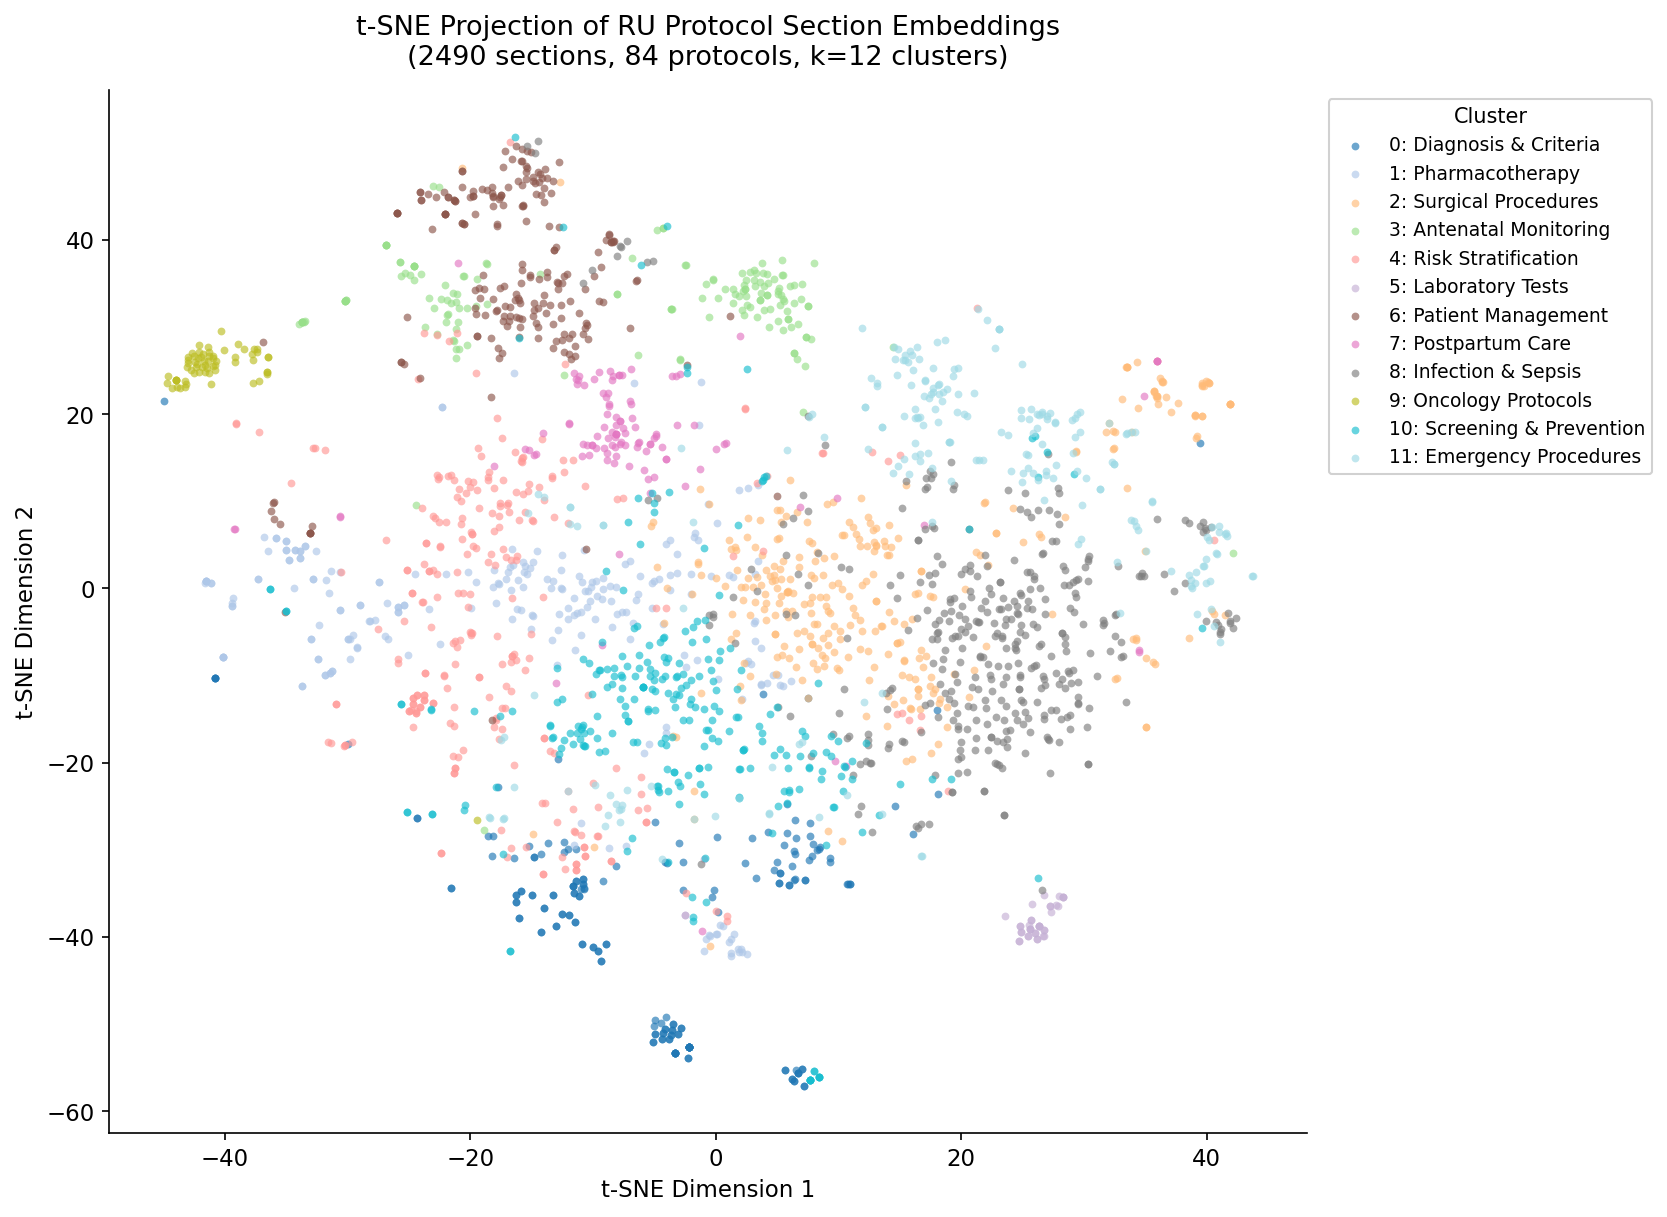

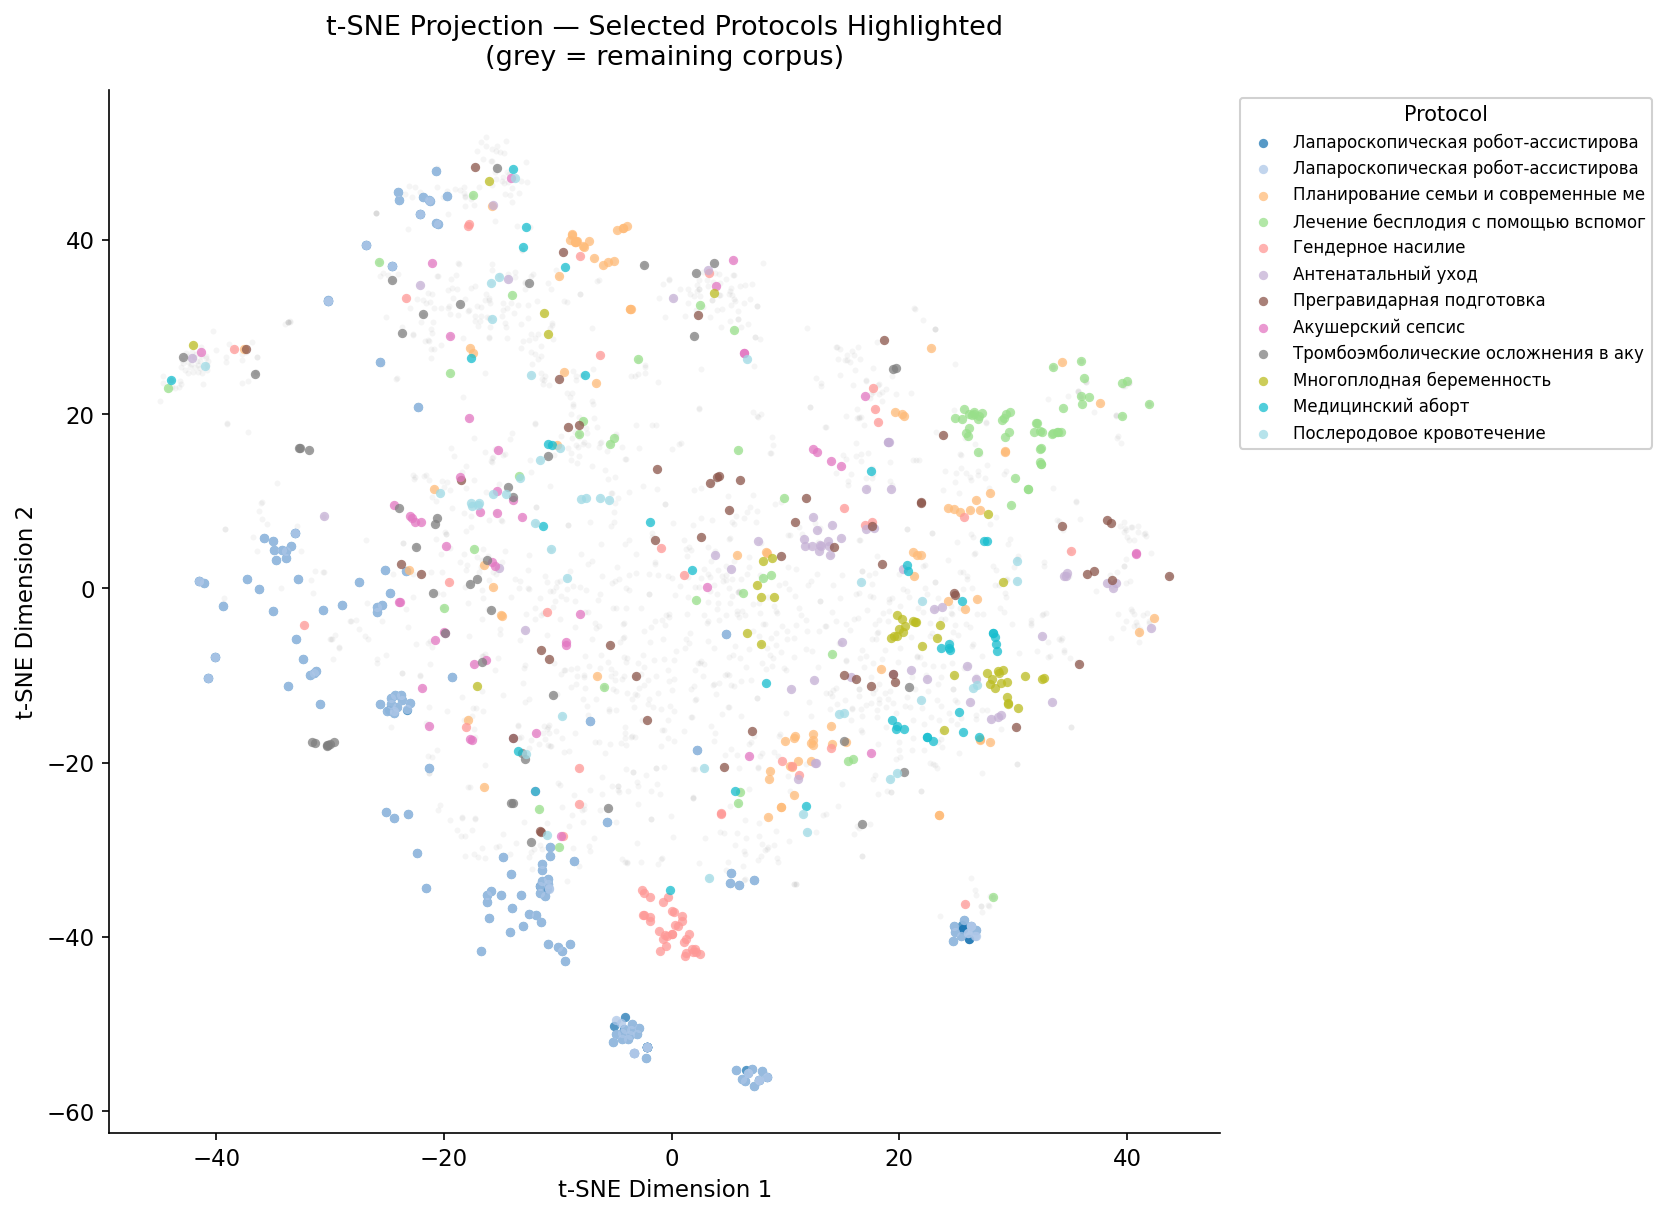

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

colors = plt.cm.tab20(np.linspace(0, 1, N_CLUSTERS))
for c in sorted(df['cluster'].unique()):
    mask  = df['cluster'] == c
    label = CLUSTER_LABELS.get(c, f'Cluster {c}')
    ax.scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
               s=14, alpha=0.65, color=colors[c],
               label=f'{c}: {label}', linewidths=0)

ax.set_title(
    't-SNE Projection of RU Protocol Section Embeddings\n'
    f'({len(df)} sections, {df["protocol"].nunique()} protocols, k={N_CLUSTERS} clusters)',
    pad=12
)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, title_fontsize=10, framealpha=0.9)

fig.savefig(PLOT_DIR / 'fig_tsne_clusters.png', bbox_inches='tight')
plt.show()

sampled_protocols = df['protocol'].value_counts().head(12).index.tolist()
df_sub  = df[df['protocol'].isin(sampled_protocols)].copy()
p_colors = plt.cm.tab20(np.linspace(0, 1, len(sampled_protocols)))
p_color_map = {p: p_colors[i] for i, p in enumerate(sampled_protocols)}

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(df['tsne_x'], df['tsne_y'], s=8, alpha=0.08, color='grey', linewidths=0)
for proto in sampled_protocols:
    mask = df_sub['protocol'] == proto
    ax.scatter(df_sub.loc[mask, 'tsne_x'], df_sub.loc[mask, 'tsne_y'],
               s=20, alpha=0.75, color=p_color_map[proto],
               label=proto.replace('_', ' ')[:35], linewidths=0)
ax.set_title(
    't-SNE Projection — Selected Protocols Highlighted\n'
    '(grey = remaining corpus)',
    pad=12
)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Protocol', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, title_fontsize=10, framealpha=0.9)
fig.savefig(PLOT_DIR / 'fig_tsne_protocols.png', bbox_inches='tight')
plt.show()

Mean intra-cluster cosine similarity : 0.5800
Mean inter-cluster cosine similarity : 0.3704
Separation ratio (intra/inter)       : 1.5658


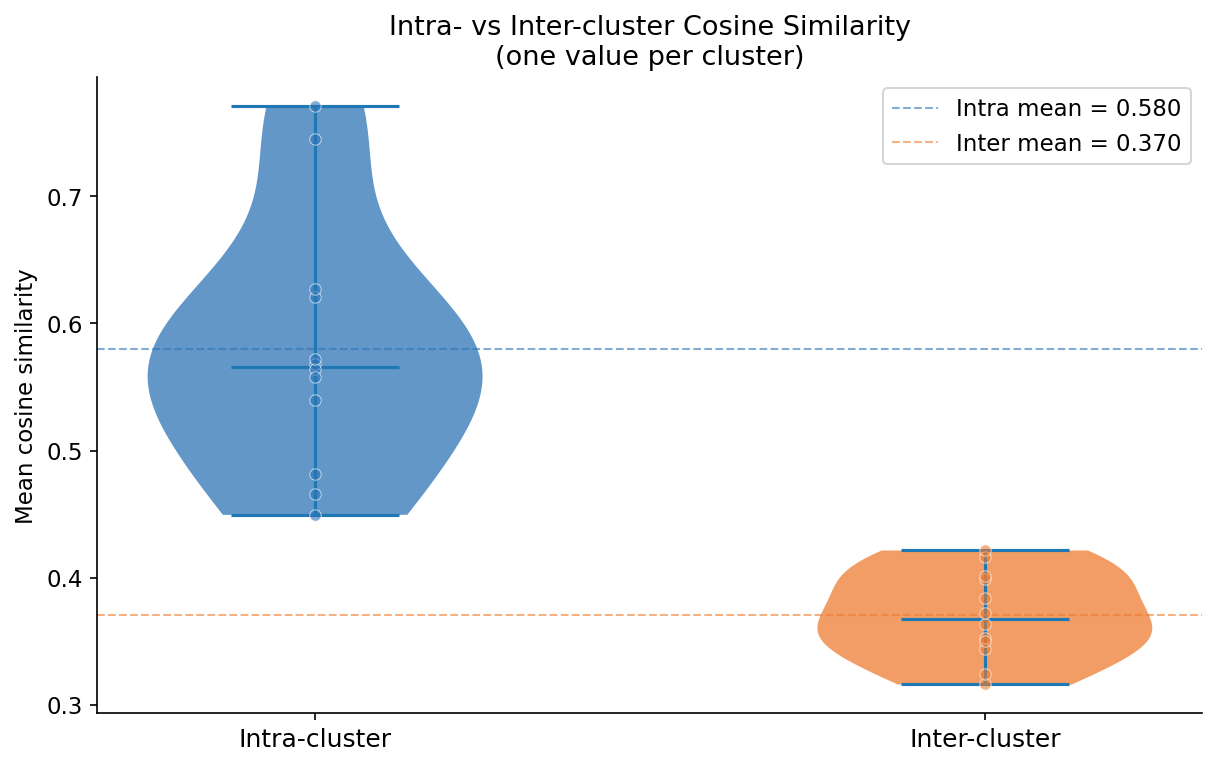

In [ ]:
X_norm = normalize(X, norm='l2')

SAMPLE = 80
intra_sims = []
inter_sims = []

cluster_ids = sorted(df['cluster'].unique())
for c in cluster_ids:
    idx_c = np.where(labels == c)[0]
    if len(idx_c) > SAMPLE:
        idx_c = np.random.choice(idx_c, SAMPLE, replace=False)
    idx_other = np.where(labels != c)[0]
    if len(idx_other) > SAMPLE:
        idx_other = np.random.choice(idx_other, SAMPLE, replace=False)

    # intra
    if len(idx_c) > 1:
        S_intra = X_norm[idx_c] @ X_norm[idx_c].T
        triu = S_intra[np.triu_indices_from(S_intra, k=1)]
        intra_sims.append(float(triu.mean()))

    # inter
    if len(idx_c) > 0 and len(idx_other) > 0:
        S_inter = X_norm[idx_c] @ X_norm[idx_other].T
        inter_sims.append(float(S_inter.mean()))

mean_intra = np.mean(intra_sims)
mean_inter = np.mean(inter_sims)

print(f'Mean intra-cluster cosine similarity : {mean_intra:.4f}')
print(f'Mean inter-cluster cosine similarity : {mean_inter:.4f}')
print(f'Separation ratio (intra/inter)       : {mean_intra/mean_inter:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot([intra_sims, inter_sims], positions=[1, 2],
                      showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('#2E75B6')
parts['bodies'][1].set_facecolor('#ED7D31')
for pc in parts['bodies']:
    pc.set_alpha(0.75)

ax.scatter([1]*len(intra_sims), intra_sims, s=30, zorder=3,
           color='#2E75B6', alpha=0.6, edgecolors='white', linewidths=0.5)
ax.scatter([2]*len(inter_sims), inter_sims, s=30, zorder=3,
           color='#ED7D31', alpha=0.6, edgecolors='white', linewidths=0.5)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Intra-cluster', 'Inter-cluster'], fontsize=12)
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Intra- vs Inter-cluster Cosine Similarity\n(one value per cluster)')
ax.axhline(mean_intra, color='#2E75B6', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Intra mean = {mean_intra:.3f}')
ax.axhline(mean_inter, color='#ED7D31', linestyle='--', linewidth=1,
           alpha=0.6, label=f'Inter mean = {mean_inter:.3f}')
ax.legend()
fig.savefig(PLOT_DIR / 'fig_intra_inter_similarity.png', bbox_inches='tight')
plt.show()

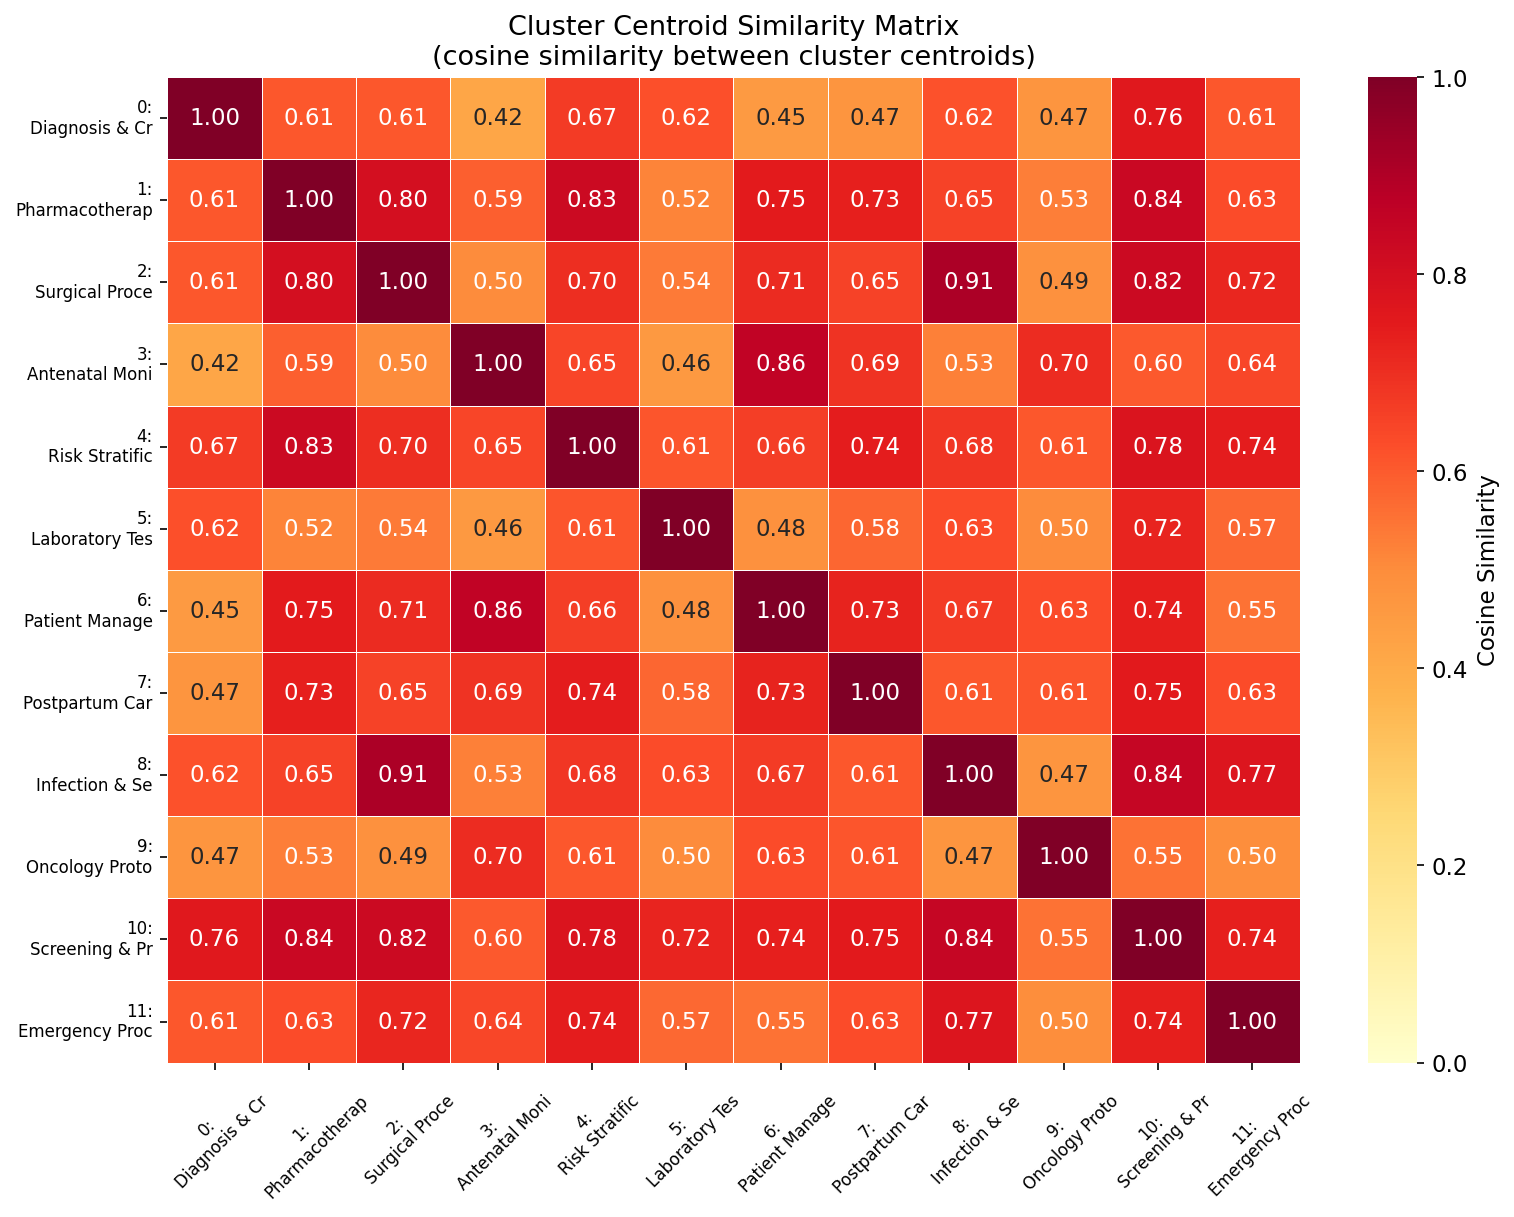

In [ ]:
centroids = np.array([
    X_norm[labels == c].mean(axis=0) for c in cluster_ids
])
centroids = normalize(centroids, norm='l2')
C_sim = centroids @ centroids.T

tick_labels = [f'{c}:\n{CLUSTER_LABELS.get(c, "")[:14]}' for c in cluster_ids]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    C_sim, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=tick_labels, yticklabels=tick_labels,
    vmin=0, vmax=1, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Cosine Similarity'},
)
ax.set_title('Cluster Centroid Similarity Matrix\n'
             '(cosine similarity between cluster centroids)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
fig.savefig(PLOT_DIR / 'fig_cluster_centroid_heatmap.png', bbox_inches='tight')
plt.show()

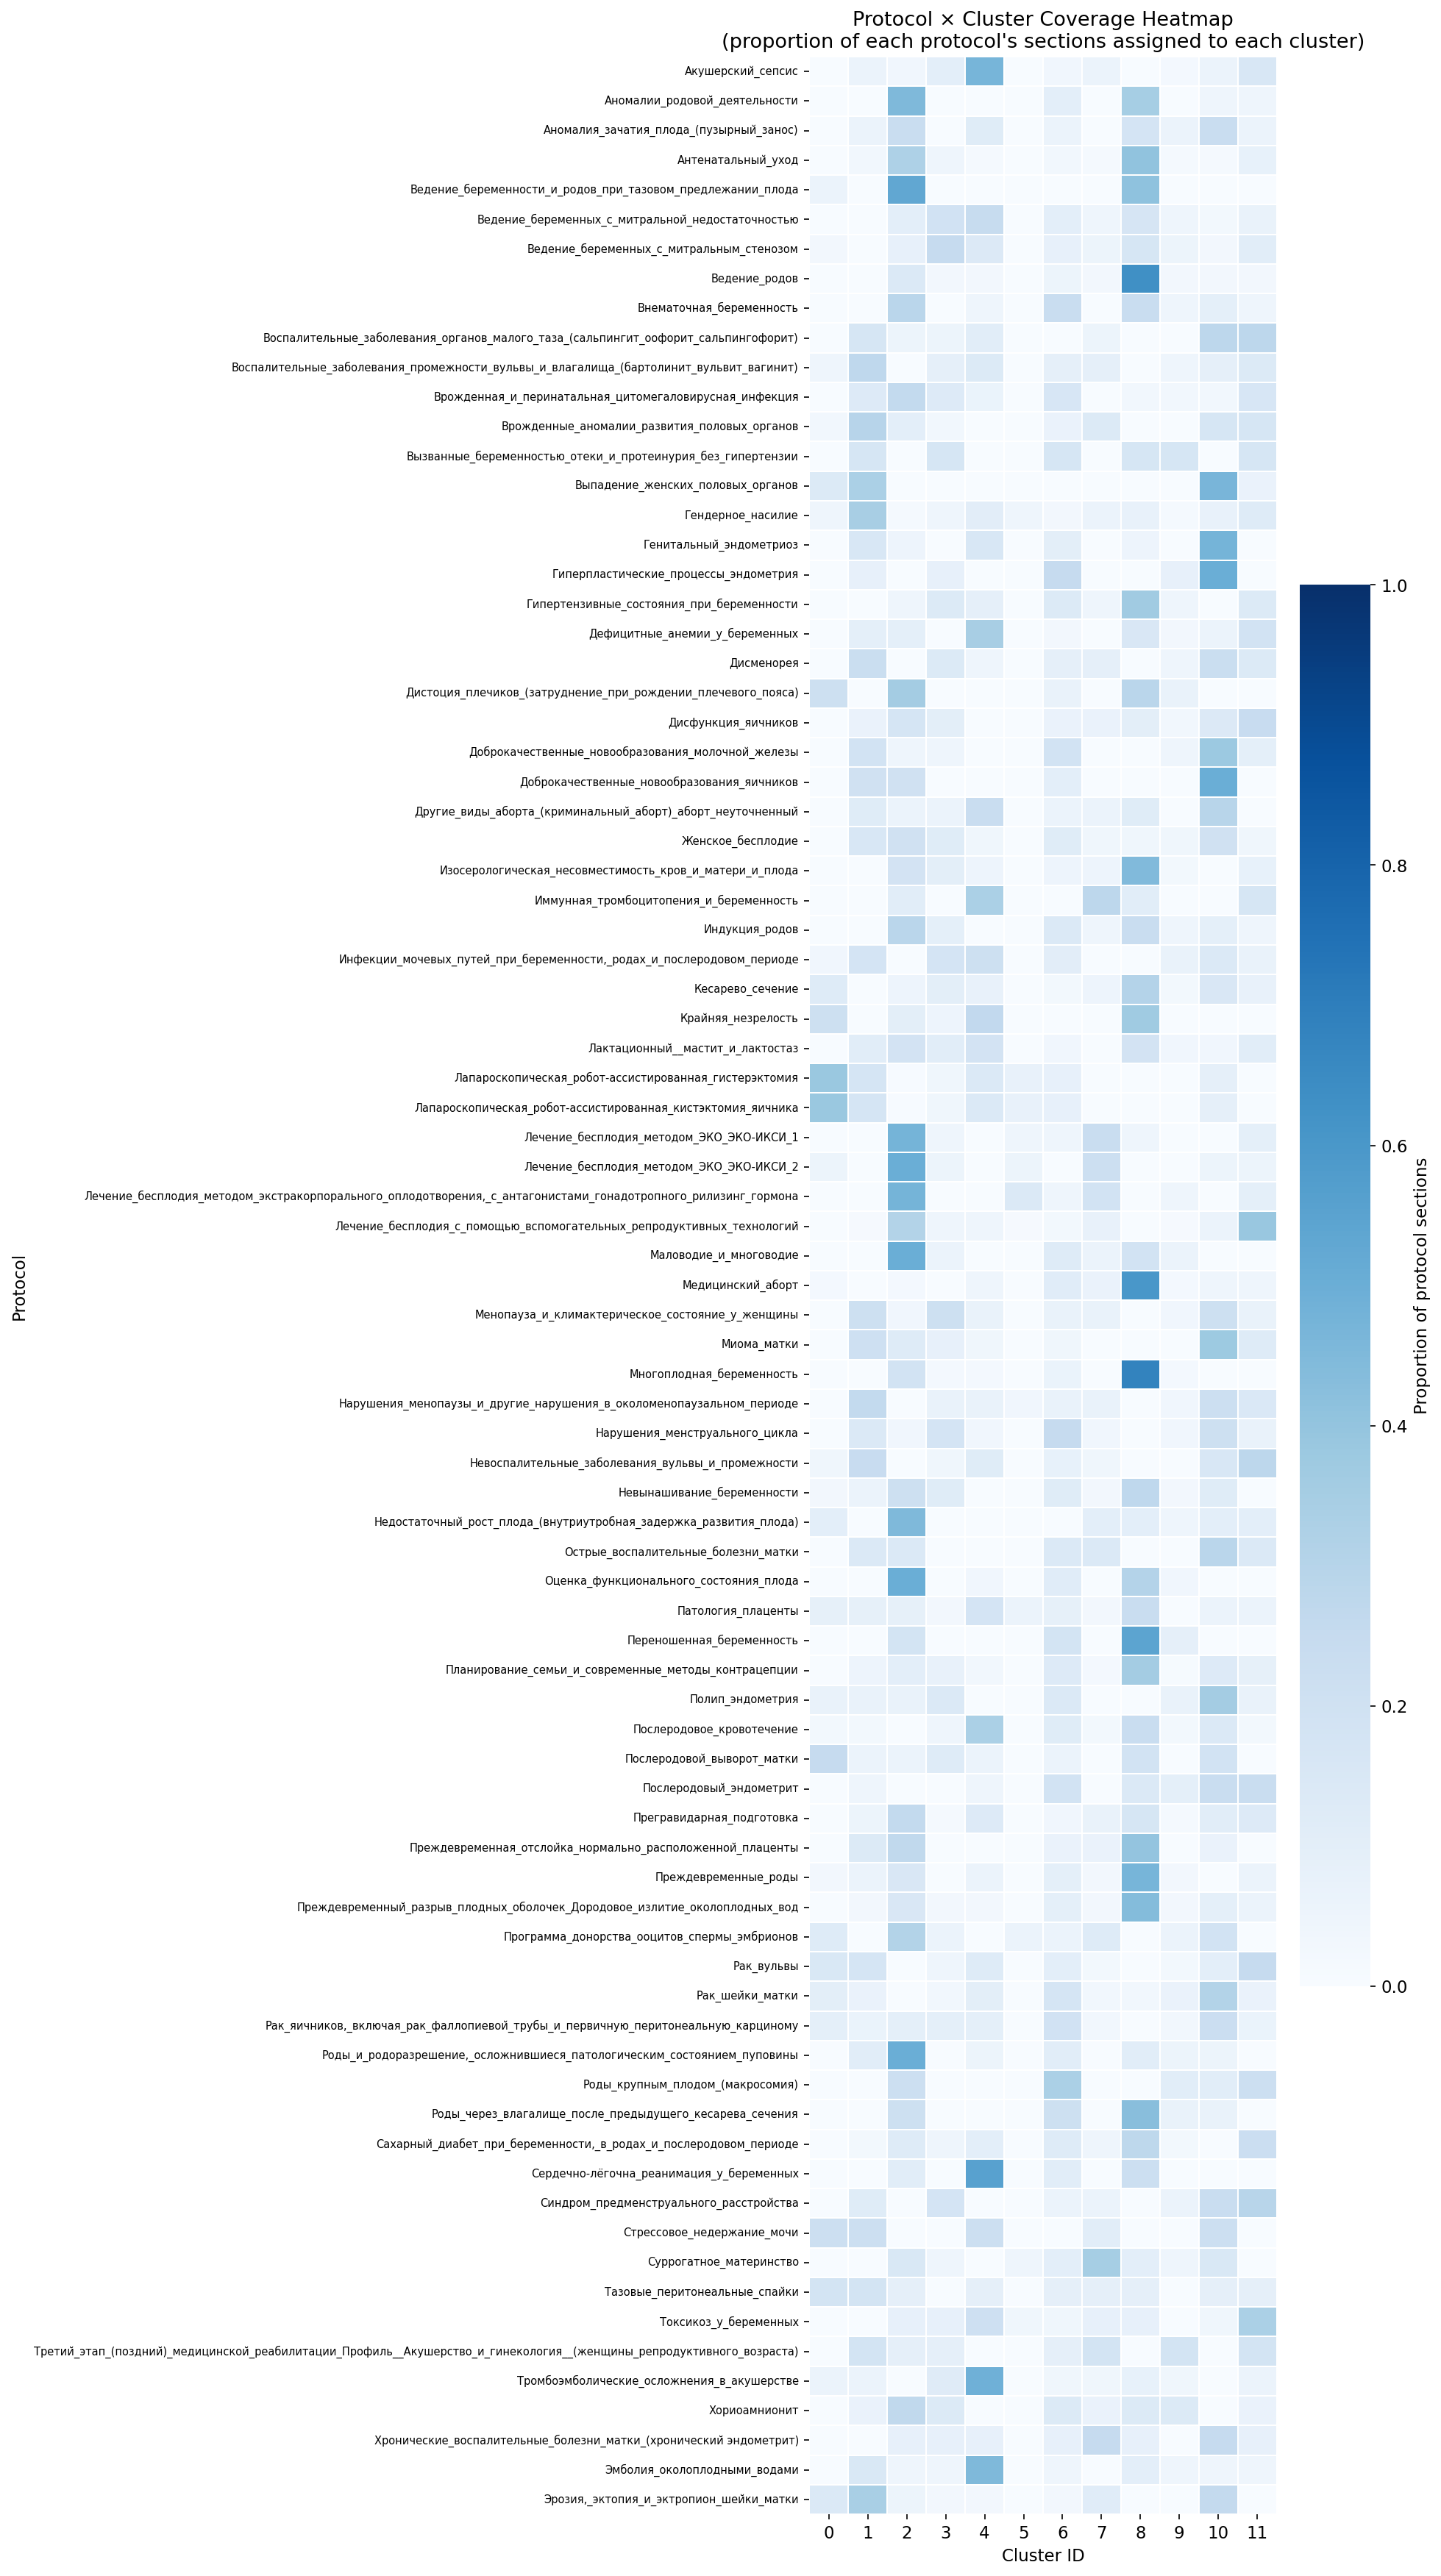

Coverage heatmap: 83 protocols × 12 clusters


In [ ]:
coverage = (
    df.groupby(['protocol', 'cluster'])
    .size()
    .unstack(fill_value=0)
)
coverage_pct = coverage.div(coverage.sum(axis=1), axis=0).round(3)

min_sections = 3
coverage_pct = coverage_pct[coverage.sum(axis=1) >= min_sections]

fig, ax = plt.subplots(figsize=(13, max(6, len(coverage_pct) * 0.28)))
sns.heatmap(
    coverage_pct, cmap='Blues', ax=ax,
    vmin=0, vmax=1, linewidths=0.2,
    xticklabels=[f'{c}' for c in coverage_pct.columns],
    cbar_kws={'label': 'Proportion of protocol sections'},
)
ax.set_title('Protocol × Cluster Coverage Heatmap\n'
             '(proportion of each protocol\'s sections assigned to each cluster)')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Protocol')
ax.tick_params(axis='y', labelsize=7)
fig.savefig(PLOT_DIR / 'fig_protocol_cluster_coverage.png', bbox_inches='tight')
plt.show()
print(f'Coverage heatmap: {len(coverage_pct)} protocols × {len(coverage_pct.columns)} clusters')

In [ ]:
summary = {
    'n_protocols':            int(df['protocol'].nunique()),
    'n_sections_total':       int(len(df)),
    'n_sections_mean_per_protocol': round(float(df.groupby('protocol').size().mean()), 2),
    'n_sections_std_per_protocol':  round(float(df.groupby('protocol').size().std()),  2),
    'section_chars_mean':     round(float(df['section_chars'].mean()), 1),
    'section_chars_median':   round(float(df['section_chars'].median()), 1),
    'section_chars_std':      round(float(df['section_chars'].std()), 1),
    'embedding_dim':          int(X.shape[1]),
    'n_clusters':             int(N_CLUSTERS),
    'silhouette_global':      round(float(sil_global), 4),
    'silhouette_best_k':      int(best_k),
    'silhouette_best_k_score': round(float(max(sil_scores)), 4),
    'mean_intra_cluster_cosine': round(float(mean_intra), 4),
    'mean_inter_cluster_cosine': round(float(mean_inter), 4),
    'separation_ratio':       round(float(mean_intra / mean_inter), 4),
    'min_chars_threshold':    int(MIN_CHARS),
    'embedding_model':        MODEL_NAME,
}

summary_path = OUTPUT_DIR / 'ru_corpus_validation_summary.json'
summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('\n' + '='*55)
print('  RU CORPUS STRUCTURAL VALIDATION — SUMMARY')
print('='*55)
for k, v in summary.items():
    print(f'  {k:<40} {v}')
print('='*55)
print(f'\nSaved: {summary_path}')


  RU CORPUS STRUCTURAL VALIDATION — SUMMARY
  n_protocols                              84
  n_sections_total                         2490
  n_sections_mean_per_protocol             29.64
  n_sections_std_per_protocol              26.59
  section_chars_mean                       1515.9
  section_chars_median                     685.5
  section_chars_std                        4094.0
  embedding_dim                            768
  n_clusters                               12
  silhouette_global                        0.0694
  silhouette_best_k                        18
  silhouette_best_k_score                  0.0796
  mean_intra_cluster_cosine                0.58
  mean_inter_cluster_cosine                0.3704
  separation_ratio                         1.5658
  min_chars_threshold                      200
  embedding_model                          sentence-transformers/paraphrase-multilingual-mpnet-base-v2

Saved: /content/drive/MyDrive/medical_protocols/ru_embeddings/ru_corpus_vali

In [ ]:
df.to_csv(OUTPUT_DIR / 'ru_clusters_sections.csv', index=False)

df_titles.to_csv(OUTPUT_DIR / 'ru_cluster_top_titles.csv', index=False)

cluster_sizes_full = (
    df.groupby(['cluster', 'cluster_label'])
    .agg(
        n_sections=('section_id', 'count'),
        mean_chars=('section_chars', 'mean'),
        mean_silhouette=('silhouette_sample', 'mean'),
    )
    .reset_index()
    .sort_values('n_sections', ascending=False)
    .round(3)
)
cluster_sizes_full.to_csv(OUTPUT_DIR / 'ru_cluster_summary.csv', index=False)

print('All outputs saved:')
for f in sorted(OUTPUT_DIR.glob('*.csv')) + sorted(OUTPUT_DIR.glob('*.json')) + sorted(PLOT_DIR.glob('*.png')):
    print(f'  {f.relative_to(OUTPUT_DIR.parent)}')

print('\nFinal cluster summary table:')
display(cluster_sizes_full)

All outputs saved:
  ru_embeddings/ru_cluster_summary.csv
  ru_embeddings/ru_cluster_top_titles.csv
  ru_embeddings/ru_clusters_sections.csv
  ru_embeddings/ru_corpus_validation_summary.json
  ru_embeddings/ru_sections_Акушерский_сепсис.json
  ru_embeddings/ru_sections_Аномалии_родовой_деятельности.json
  ru_embeddings/ru_sections_Аномалия_зачатия_плода_(пузырный_занос).json
  ru_embeddings/ru_sections_Антенатальный_уход.json
  ru_embeddings/ru_sections_Ведение_беременности_и_родов_при_тазовом_предлежании_плода.json
  ru_embeddings/ru_sections_Ведение_беременных_с_митральной_недостаточностью.json
  ru_embeddings/ru_sections_Ведение_беременных_с_митральным_стенозом.json
  ru_embeddings/ru_sections_Ведение_родов.json
  ru_embeddings/ru_sections_Внематочная_беременность.json
  ru_embeddings/ru_sections_Воспалительные_заболевания_органов_малого_таза_(сальпингит_оофорит_сальпингофорит).json
  ru_embeddings/ru_sections_Воспалительные_заболевания_промежности_вульвы_и_влагалища_(бартолини

,cluster,cluster_label,n_sections,mean_chars,mean_silhouette
8,8,Infection & Sepsis,386,1625.117,0.059
2,2,Surgical Procedures,319,958.690,0.053
10,10,Screening & Prevention,272,911.202,0.026
4,4,Risk Stratification,271,1113.111,0.015
1,1,Pharmacotherapy,241,1006.108,0.001
11,11,Emergency Procedures,223,1120.879,0.027
6,6,Patient Management,211,2227.019,0.106
0,0,Diagnosis & Criteria,192,1580.474,0.194
3,3,Antenatal Monitoring,157,4687.484,0.033
7,7,Postpartum Care,112,1110.366,0.092
